RQ4 – Discount vs profit margin

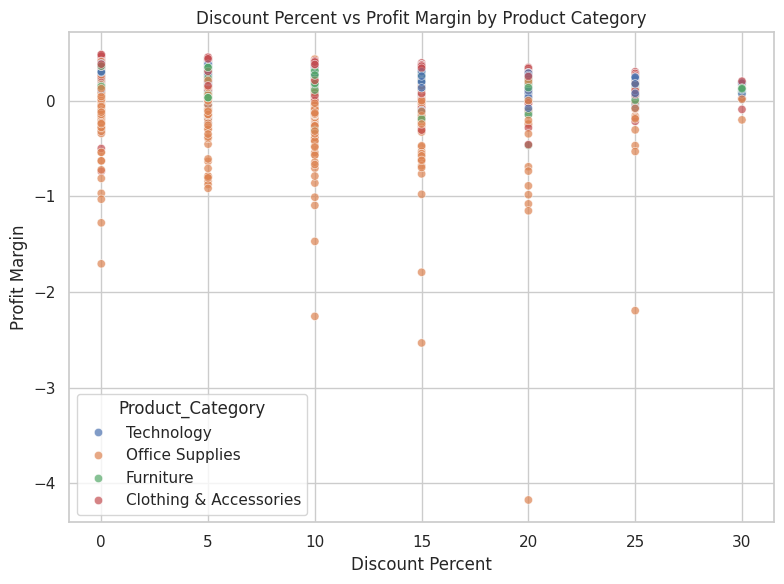

In [12]:
# RQ4: Discount vs profit margin

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# -------------------
# 1. Load data
# -------------------
DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 1. Compute profit margin
# -------------------
df['Profit_Margin'] = np.where(
    df['Total_Sales'] != 0,
    df['Profit'] / df['Total_Sales'],
    np.nan
)

# -------------------
# 2. Aggregate by Product_Category
# -------------------
disc_margin_cat = (
    df.groupby('Product_Category', as_index=False)
      .agg(
          Avg_Discount_Percent=('Discount_Percent', 'mean'),
          Avg_Profit_Margin=('Profit_Margin', 'mean')
      )
)

disc_margin_cat.to_csv(OUTPUT_DIR / "RQ4_Table_Discount_ProfitMargin_ByCategory.csv", index=False)

# -------------------
# 3. Scatter plot
# -------------------
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Discount_Percent',
    y='Profit_Margin',
    hue='Product_Category',
    alpha=0.7
)
plt.title("Discount Percent vs Profit Margin by Product Category")
plt.xlabel("Discount Percent")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ4_Figure1_Discount_ProfitMargin_Scatter.pdf", format="pdf")
plt.show()
plt.close()

### Interpretation of chart.

- Higher discounts generally correlate with lower profit margins, as visible from many points trending downward as discount percent increases.

- Office Supplies and Clothing & Accessories show the most negative profit margins, indicating these categories are highly sensitive to discounting.

- Technology products cluster closer to zero profit margin, suggesting they maintain profitability even with moderate discounts.

- Furniture shows a wide spread, meaning some furniture items remain profitable despite discounts, while others drop sharply into negative margins.

- Several observations fall below zero profit margin, confirming that discounts can push certain products into loss‑making territory.

- No strong positive relationship exists—higher discounts rarely lead to higher profit margins in any category.

- Category‑wise separation is visible, showing that pricing and discount strategies impact categories differently.